# Active Lives 2021-22 — London EDA & Multi-Pillar Analysis (Wave 7)

Uses the shared `active_lives_utils` module. **All wave-specific settings below are verified**
against this wave's own `.sav` (validate_wave PASS, codebook compared, borough mapping GSS-proven).

> **2021-22 is the mid-pandemic wave** — a genuine dip in activity is plausible and would be a real
> finding, not an error.

### Verified differences from the 2022-23 baseline
- **Geography column is `LA_2020`** (this file has no `LA_2021`).
- **Borough codes are swapped** vs the shared map for 4 boroughs (8↔9 Barnet/Barking & Dagenham,
  138↔139 K&C/Islington). Handled by deriving this wave's map from its **own `.sav` labels**
  (`build_london_map_from_sav` below) — correct by construction, GSS-proven.
- **Indoor/outdoor & volunteering vars carry no `.sav` labels** — standard labels applied manually
  (data present: indoor/outdoor n=6,167 each).
- **Codebook otherwise matches baseline** — `health`, `Eth7`, `NSSEC5` all coded as 2022-23
  (health IS present here, unlike 2016-17).

## 1. Imports & load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import pyreadstat
from active_lives_utils import (decode, london_filter, weighted_share,
                                weighted_distribution, check_routing, validate_wave)

CSV = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y7_2021-22.csv"
SAV = r"C:\Users\Lenovo\London-Sport-Forecasting-Patterns\data\raw\active_lives_survey_nov_21-22_data_year_7_shared_20250103.sav"  # <-- set 2021-22 .sav path
df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique() if "survey_year" in df else "?")

shape: (16139, 590) | year: ['2021-22']


## 2. Build this wave's borough map from its OWN .sav (GSS-correct by construction)

In [2]:
def build_london_map_from_sav(sav_path, la_col):
    """Derive {code: (gss, name)} for London boroughs directly from a wave's .sav value labels.
    This is the robust approach: each wave self-describes its boroughs, so per-wave code
    differences (like the 2021-22 swaps) never cause mislabelling. GSS is the invariant join key."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    m = {}
    for code, lbl in labels.items():
        s = str(lbl)
        if s.startswith("E09"):
            gss = s.split()[0]
            m[int(code)] = (gss, s[len(gss):].strip())
    return m

LA_COL = "LA_2020"
LONDON_MAP = build_london_map_from_sav(SAV, LA_COL)
print(f"{len(LONDON_MAP)} London codes derived from {LA_COL}")

# Prove it: every code's GSS must match its borough name's GSS (self-consistency)
def verify_borough_mapping(sav_path, la_col, london_map):
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    mism = [f"code {c}: map {g} {n} vs .sav {labels.get(c)!r}"
            for c,(g,n) in london_map.items()
            if labels.get(c) is not None and g not in str(labels.get(c))]
    print("=== verify_borough_mapping ->", "PROVEN OK" if not mism else f"{len(mism)} MISMATCH", "===")
    for x in mism: print("  -", x)
    return mism
verify_borough_mapping(SAV, LA_COL, LONDON_MAP)

33 London codes derived from LA_2020
=== verify_borough_mapping -> PROVEN OK ===


[]

## 3. Validate the wave

In [3]:
df["LA_2021"] = df[LA_COL]   # alias so validate_wave's LA_2021 borough check works
# Coverage is checked against THIS wave's map below; validate_wave's internal check uses the shared
# map and may under-report, so we also print our own coverage.
validate_wave(df, "2021-22", expected_active=0.63, tol=0.06)
print("coverage (this wave's map):",
      round(df[LA_COL].map({k:v[0] for k,v in LONDON_MAP.items()}).notna().mean(), 3))

=== validate_wave: 2021-22 -> PASS ===
coverage (this wave's map): 1.0


## 4. Codebook & config (verified against this wave's .sav)

In [4]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "Gend3": {1: "Male", 2: "Female", 3: "Other"},
    "Eth7":  {1: "White British", 2: "White Other", 3: "Asian (excl. Chinese)",
              4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9": {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
             6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)", 4: "Students and other (NS-SEC 9)",
               5: "Aged <16 or 75+ (outside classification)"},
    "Educ6": {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
              4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "health": {1: "Very good", 2: "Good", 3: "Fair", 4: "Bad", 5: "Very bad"},
    "BMIG": {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese", 5: "Morbidly obese"},
    "VolAny": {0: "Did not volunteer", 1: "Volunteered"},
}
VOL_ROLES = {
    "volint1_vol": "Raising funds", "volint2_vol": "Providing transport",
    "volint3_vol": "Coaching/instructing", "volint4_vol": "Refereeing/officiating",
    "volint5_vol": "Administrative/committee role", "volint6_vol": "Stewarding/marshalling",
    "volint7_vol": "Other help",
}
CONFIG = {
    "weight":"wt_final", "la_code":LA_COL,
    "activity_band":"MEMS7GR_SPORTCOUNT_A01",
    "activity_in":"MEMS7GR_IN_SPORTCOUNT_A01", "activity_out":"MEMS7GR_OUT_SPORTCOUNT_A01",
    "age":"Age9", "gender":"Gend3", "ethnicity":"Eth7", "disability":"Disab3",
    "nssec":"NSSEC5", "education":"Educ6", "bmi":"BMIG", "volunteer":"VolAny", "health":"health",
}

## 5. Decode & build the London frame

In [5]:
if "Age9" in df.columns:
    df = df[df["Age9"] != 1.0].copy()
CONFIG = {k:v for k,v in CONFIG.items() if (k=="weight" or v in df.columns)}
data = decode(df, CONFIG, CODEBOOK)
london = london_filter(data, la_col=LA_COL, la_map=LONDON_MAP)
print(f"London frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs (expect 32)")

London frame: 16,139 rows, 32 boroughs (expect 32)


## 6. Missingness & routing

In [6]:
concept_cols = [c for c in ["activity_band","activity_in","activity_out","age","gender",
    "ethnicity","disability","nssec","education","health","bmi","volunteer","weight"] if c in london.columns]
print((london[concept_cols].isna().mean()*100).round(1).sort_values(ascending=False).to_string())
role_cols=[c for c in london.columns if c.startswith("volint")]
if role_cols: check_routing(london,"volunteer","Volunteered",role_cols,"Volunteer -> role detail")
disty=[c for c in london.columns if c.startswith("disty")]
if disty: check_routing(london,"disability","Limiting disability",disty,"Limiting disability -> impairment")

activity_in      61.8
activity_out     61.8
volunteer        24.0
bmi              19.0
nssec             7.4
ethnicity         7.2
disability        7.0
education         3.3
health            2.2
age               0.8
gender            0.2
activity_band     0.0
weight            0.0
Volunteer -> role detail=='Volunteered' (n=1908): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment=='Limiting disability' (n=2529): max dep-missing=0.029, all-blank=74 (2.9%)


## 7. Pillar 1 — Participation

In [7]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2021-22): {overall:.3f}   (2015-16:0.635 | 2016-17:0.623 | 2022-23:0.643)")
for f in ["age","gender","ethnicity","disability","nssec","education","health","bmi"]:
    if f in london.columns:
        print(f"\n=== % Active by {f} ===")
        print(weighted_share(london,[f],"activity_band","Active").dropna(subset=[f]).to_string(index=False))

Overall London % Active (2021-22): 0.643   (2015-16:0.635 | 2016-17:0.623 | 2022-23:0.643)

=== % Active by age ===
  age  weighted_share    n
16-24        0.674217 1299
25-34        0.705257 3039
35-44        0.648878 3371
45-54        0.655843 2711
55-64        0.633346 2465
65-74        0.614262 1932
75-84        0.438472  943
  85+        0.266597  244

=== % Active by gender ===
gender  weighted_share    n
Female        0.606858 8847
  Male        0.682133 7146
 Other        0.543463  121

=== % Active by ethnicity ===
            ethnicity  weighted_share    n
Asian (excl. Chinese)        0.577423 2335
                Black        0.541593 1038
              Chinese        0.617163  355
                Mixed        0.712255  531
   Other ethnic group        0.572937  459
        White British        0.699641 7715
          White Other        0.694166 2545

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.518735  2529
  

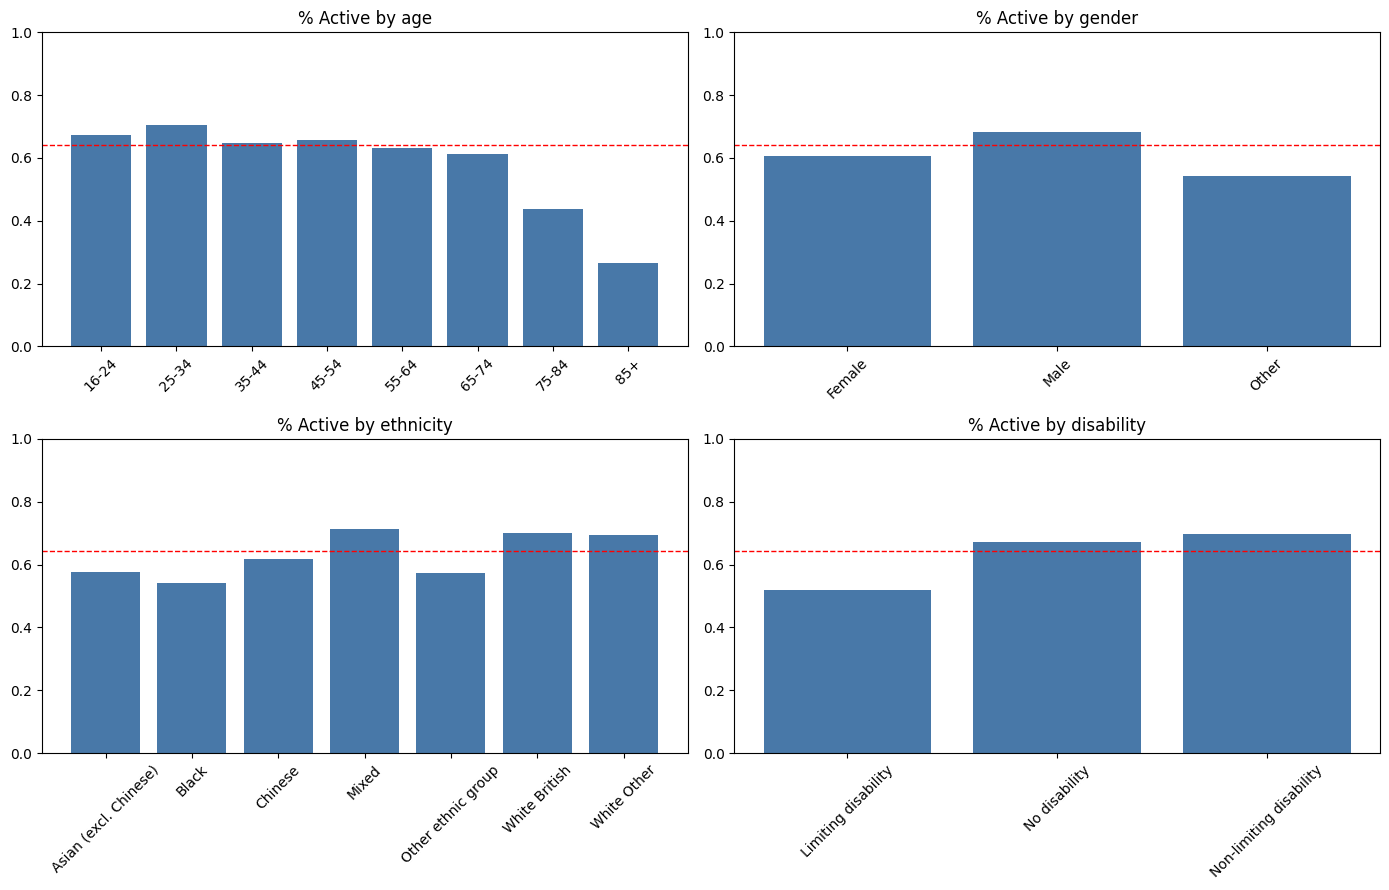

In [8]:
factors=[f for f in ["age","gender","ethnicity","disability"] if f in london.columns]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax,f in zip(axes.ravel(), factors):
    r = weighted_share(london,[f],"activity_band","Active").dropna(subset=[f])
    ax.bar(r[f].astype(str), r["weighted_share"], color="#4878a8"); ax.set_ylim(0,1)
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_title(f"% Active by {f}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share   n
  Barking and Dagenham        0.519159 519
              Havering        0.553039 515
                 Brent        0.575255 512
               Enfield        0.579663 506
                Sutton        0.588967 521
              Hounslow        0.593846 496
                Harrow        0.597483 518
             Greenwich        0.599182 496
               Croydon        0.599206 497
                Bexley        0.600904 487
             Redbridge        0.602397 498
            Hillingdon        0.608506 485
                Newham        0.611359 501
        Waltham Forest        0.618123 498
Kensington and Chelsea        0.623625 512
                Merton        0.636813 497
                Barnet        0.637448 506
                Ealing        0.642205 485
             Southwark        0.657669 521
              Haringey        0.661339 490
         Tower Hamlets        0.667439 540
               Lambeth        0.690080 501
           

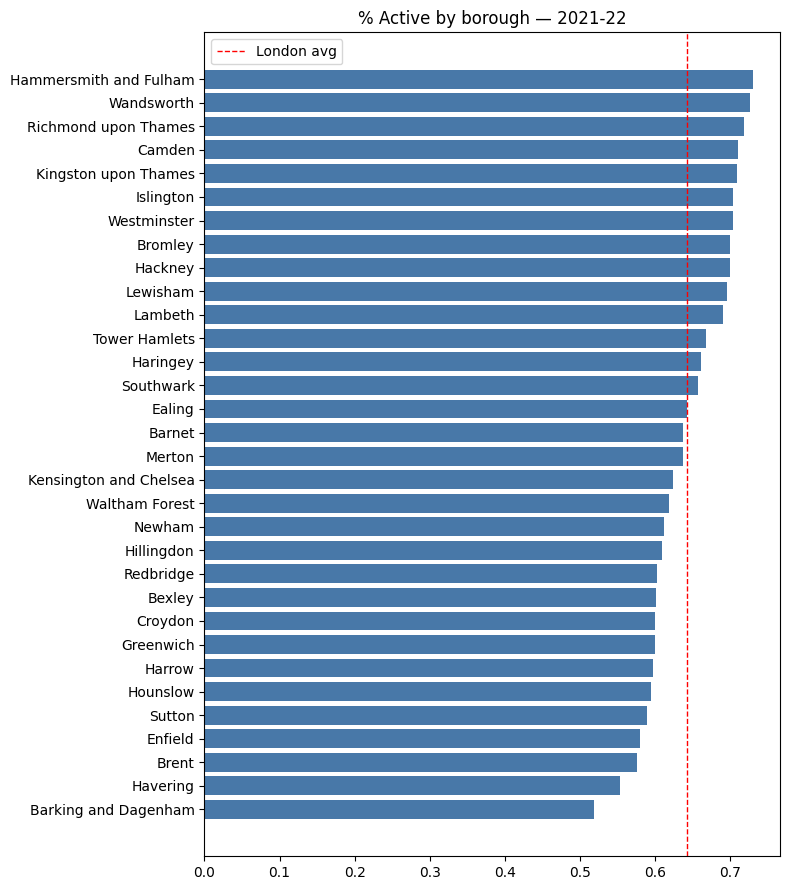

In [9]:
bor = weighted_share(london,["LA_name"],"activity_band","Active").sort_values("weighted_share")
print(bor.to_string(index=False))
fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_title("% Active by borough — 2021-22"); ax.legend(); plt.tight_layout(); plt.show()

## 8. Pillar 3 — Indoor vs Outdoor (manual labels; subgroup ~6,167)

In [10]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,}")
for place,col in [("Indoor","activity_in"),("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io,[],col,'Active'):.3f}")

Indoor/outdoor base: 6,167 of 16,139
Indoor: weighted % active = 0.234
Outdoor: weighted % active = 0.575


## 9. Pillar 4 — Volunteering

In [11]:
print(f"Overall weighted % volunteered: {weighted_share(london,[],'volunteer','Volunteered'):.3f}   (2016-17:0.229 | 2022-23:0.183)")
for f in ["age","gender","disability","nssec"]:
    if f in london.columns:
        print(f"\n=== % Volunteered by {f} ===")
        print(weighted_share(london,[f],"volunteer","Volunteered").dropna(subset=[f]).to_string(index=False))
vols = london[london["volunteer"]=="Volunteered"].dropna(subset=["weight"]).copy()
rs={}
for col,label in VOL_ROLES.items():
    if col in vols.columns:
        d=vols.dropna(subset=[col]); rs[label]=(d[col]*d["weight"]).sum()/d["weight"].sum()
if rs: print("\nRole mix:"); print(pd.Series(rs).sort_values(ascending=False).round(3).to_string())

Overall weighted % volunteered: 0.167   (2016-17:0.229 | 2022-23:0.183)

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.225751 1130
25-34        0.146720 2678
35-44        0.156252 2841
45-54        0.179066 2134
55-64        0.168711 1752
65-74        0.144054 1145
75-84        0.157104  433
  85+        0.027594   96

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.136315 6639
  Male        0.196026 5519
 Other        0.251072  111

=== % Volunteered by disability ===
             disability  weighted_share    n
    Limiting disability        0.142361 1604
          No disability        0.165895 8226
Non-limiting disability        0.201875 1505

=== % Volunteered by nssec ===
                            nssec  weighted_share    n
Higher social groups (NS-SEC 1-2)        0.182722 7588
 Lower social groups (NS-SEC 6-8)        0.109859 1109
Middle social groups (NS-SEC 3-5)        0.153016 1958
    Students and other (NS-SEC 9)        

## 10. Pillar 2 — Regression (health included for this wave)

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
terms = ['C(age)','C(gender, Treatment(reference="Female"))',
         'C(disability, Treatment(reference="No disability"))',
         'C(ethnicity, Treatment(reference="White British"))']
need=["activity_band","age","gender","disability","ethnicity","weight"]
if "nssec" in london.columns: terms.append("C(nssec)"); need.append("nssec")
if "health" in london.columns: terms.append("C(health)"); need.append("health")
m = london.dropna(subset=need).copy(); m["active"]=(m["activity_band"]=="Active").astype(int)
print(f"Complete-case: {len(m):,} of {len(london):,} ({len(m)/len(london):.0%}) | health in model: {'health' in london.columns}")
model = smf.glm("active ~ "+" + ".join(terms), data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(pd.DataFrame({"odds_ratio":np.exp(model.params),"p_value":model.pvalues,
    "ci_low":np.exp(model.conf_int()[0]),"ci_high":np.exp(model.conf_int()[1])}).round(3).to_string())

Complete-case: 13,024 of 16,139 (81%) | health in model: True
                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            1.675    0.000   1.382    2.029
C(age)[T.25-34]                                                                      0.918    0.145   0.818    1.030
C(age)[T.35-44]                                                                      0.759    0.000   0.675    0.853
C(age)[T.45-54]                                                                      0.792    0.000   0.702    0.895
C(age)[T.55-64]                                                                      0.686    0.000   0.604    0.779
C(age)[T.65-74]                                                                      0.538    0.000   0.469    0.618
C(gender, Treatment(reference="Female"))[T.Male]                                     1.294    0.000   1.220    1.373
C(

## 11. Save & compare

In [13]:
london.to_parquet("london_2021_22_clean.parquet")
print("saved", london.shape)
print(pd.DataFrame({"wave":["2015-16","2016-17","2021-22","2022-23"],
    "pct_active":[0.635,0.623, round(weighted_share(london,[],"activity_band","Active"),3), 0.643]}).to_string(index=False))

saved (16139, 606)
   wave  pct_active
2015-16       0.635
2016-17       0.623
2021-22       0.643
2022-23       0.643


## Findings — to complete after running
- Overall active 2021-22: ___ — **pandemic dip** vs ~62-64% other waves?
- Borough range: ___ to ___.
- Volunteering: ___% | Indoor vs outdoor: ___ / ___.
- Regression: disability effect ___ (health in model, so expect it partly mediated as in 2022-23).

### Coherence for synthesis (verified)
- Borough map derived from this wave's own .sav and GSS-proven; join the panel on `gss`, not the
  integer code (2021-22 uses LA_2020 with 8↔9 / 138↔139 swaps vs other waves).